In [1]:
from DatascienceAllFunctions import DsFunctions as dsf
## Reading the data from CSV file
dataset=dsf.importDataset()

#### 1.2 1)Replace the NaN values with correct value. And justify why you have #chosen the same.

In [2]:
dataset.isnull().sum()

sl_no              0
gender             0
ssc_p              0
ssc_b              0
hsc_p              0
hsc_b              0
hsc_s              0
degree_p           0
degree_t           0
workex             0
etest_p            0
specialisation     0
mba_p              0
status             0
salary            67
dtype: int64

In [3]:
## Only Salary is having NAN Values
## The candidate whos is not placed is having Salary as NAN.
## Justification: Replacing NAN with 0 will not affect the dataset

In [4]:
## Replacing Salary with 0 where NAN values are present
dataset.fillna({'salary': 0},inplace=True)

In [5]:
#3 Recheck dataset for NAN
dataset.isnull().sum()

sl_no             0
gender            0
ssc_p             0
ssc_b             0
hsc_p             0
hsc_b             0
hsc_s             0
degree_p          0
degree_t          0
workex            0
etest_p           0
specialisation    0
mba_p             0
status            0
salary            0
dtype: int64

#### 1.3 2)How many of them are not placed?

In [6]:
notPlaced=(dataset['status'] == 'Not Placed').sum().item()
notPlaced

67

In [7]:
## Totally there are 67 persons not placed

#### 1.4 3)Find the reason for non placement from the dataset?

In [8]:
dataset.drop(columns=['sl_no'], inplace=True,axis=1) # since this column has no impact removed it from Dataset

In [9]:
# This code will give the count of students placed and not placed
dataset['status'].value_counts()

status
Placed        148
Not Placed     67
Name: count, dtype: int64

In [10]:
## Below code is used to Split the dataset for placed and Not place

placed = dataset[dataset['status'] == 'Placed']
not_placed = dataset[dataset['status'] == 'Not Placed']

In [11]:
## This code is used Verify the split 
print("Placed:", placed.shape[0])
print("Not Placed:", not_placed.shape[0])

Placed: 148
Not Placed: 67


In [12]:
## This code is used to Save the Placed and non placed students as a separate CSV's
placed.to_csv("placed_students.csv", index=False)
not_placed.to_csv("not_placed_students.csv", index=False)

In [13]:
quan1, qual1 = dsf.quanQual(placed)
quan2, qual2 = dsf.quanQual(not_placed)

In [14]:
descriptive1 = dsf.findUnivariate(placed,quan1)
descriptive2 = dsf.findUnivariate(not_placed,quan2)

In [15]:
descriptive1 = dsf.checkforOutliers(descriptive1,quan1)
descriptive2 = dsf.checkforOutliers(descriptive2,quan2)

In [16]:
lower=[]
higher=[]
descriptive1=dsf.replaceOutliersWithIQRValues(placed,descriptive1,lower,higher)
lower1=[]
higher1=[]
descriptive2=dsf.replaceOutliersWithIQRValues(not_placed,descriptive2,lower1,higher1)

In [17]:
placed[quan1].describe()

,ssc_p,hsc_p,degree_p,etest_p,mba_p,salary
count,148.000000,148.000000,148.000000,148.000000,148.000000,148.000000
mean,71.721486,69.926554,68.740541,73.238041,62.579392,288655.405405
std,8.715445,9.329268,6.518087,13.729333,5.884583,93457.452420
min,49.000000,50.830000,56.000000,50.000000,52.380000,200000.000000
25%,65.000000,63.000000,65.000000,60.000000,57.772500,240000.000000
50%,72.500000,68.000000,68.000000,72.000000,62.245000,265000.000000
75%,78.125000,75.250000,72.422500,85.000000,66.760000,300000.000000
max,89.400000,97.700000,91.000000,98.000000,77.890000,940000.000000


In [18]:
not_placed[quan2].describe()

,ssc_p,hsc_p,degree_p,etest_p,mba_p,salary
count,67.000000,67.000000,67.000000,67.000000,67.000000,67.0
mean,57.544030,58.395522,61.134179,69.587910,61.612836,0.0
std,8.394246,9.914090,6.365825,11.930687,5.705689,0.0
min,40.890000,37.000000,50.000000,50.000000,51.210000,0.0
25%,52.000000,51.000000,57.000000,60.000000,58.480000,0.0
50%,56.280000,60.330000,61.000000,67.000000,60.690000,0.0
75%,63.000000,64.000000,65.000000,76.500000,65.405000,0.0
max,77.800000,82.000000,79.000000,97.000000,75.710000,0.0


In [19]:
## SSE Metric   Not Placed Placed
##      Mean     57.5%     71.7%
##      Median   56.3%     72.5%

## HSE Metric   Not Placed Placed
##      Mean     58.4%     69.9%
##      Median   60.3%     68%

## Degree Metric   Not Placed Placed
##      Mean        61.1%     68.7%
##      Median      50%       56%

## Entrance Metric   Not Placed Placed
##          Mean     69.6%      62.3%
##          Median   67%        72%
## MBA Metric   Not Placed Placed
##     Mean      61.1%     62.5%
##     Median    60.7%     62.2%

In [20]:
## Based on the descriptive analysis above, We can clearly find 
## the students who are not doing well in Academics has a lesser chance for placement

#### 1.5 4)What kind of relation between salary and mba_p

In [21]:
## Since the question is talking about Relationship we use Correlation
quan, qual = dsf.quanQual(placed)
placed[quan].corr()

,ssc_p,hsc_p,degree_p,etest_p,mba_p,salary
ssc_p,1.000000,0.293416,0.380657,0.317892,0.430560,0.035330
hsc_p,0.293416,1.000000,0.221307,0.284672,0.329983,0.076819
degree_p,0.380657,0.221307,1.000000,0.217683,0.494093,-0.019272
etest_p,0.317892,0.284672,0.217683,1.000000,0.284143,0.178307
mba_p,0.430560,0.329983,0.494093,0.284143,1.000000,0.175013
salary,0.035330,0.076819,-0.019272,0.178307,0.175013,1.000000


In [22]:
## From the above table we can infere that relation between salary and mba_p is a positive correlation of 0.175013

#### 1.6 5)Which specialization is getting minimum salary?

In [23]:
placed.groupby('specialisation')['salary'].describe()

,count,mean,std,min,25%,50%,75%,max
specialisation,,,,,,,,
Mkt&Fin,95.0,298852.631579,108190.530165,200000.0,240000.0,270000.0,300000.0,940000.0
Mkt&HR,53.0,270377.358491,54784.271471,200000.0,240000.0,255000.0,300000.0,450000.0


In [24]:
## From the table, although the minimum salary is the same for both specializations, 
## it is evident that students specializing in Marketing & HR receive lower salaries 
## compared to Marketing & Finance at the 50%, 75%, and maximum salary levels.

#### 1.7 6)How many of them getting above 500000 salary?

In [25]:
dataset[dataset['salary'] > 500000].shape[0]

3

#### 1.8 7)Test the Analysis of Variance between etest_p and mba_p at signifance level 5%.(Make decision using Hypothesis Testing)

In [26]:
# H0 (Null Hypothesis): There is no significant difference between etest_p and mba_p
# H1 (Alternate Hypothesis): There is a significant difference between etest_p and mba_p

## We can use One way ANOVA
from scipy import stats
p_value = stats.f_oneway(dataset['etest_p'], dataset['mba_p'])

In [27]:
p_value

F_onewayResult(statistic=np.float64(98.64487057324708), pvalue=np.float64(4.672547689133573e-21))

In [28]:
## From the above tests we identified pvalue is 0.000000000000000000004672547689133573 which is lesser  than 0.05%
## Conclusion: We acccpt null hypothesis 
## There is no significant difference between etest_p and mba_p

#### 1.9 8)Test the similarity between the degree_t(Sci&Tech) and specialisation(Mkt&HR) with respect to salary

In [29]:
## Hypothesis testing

# H₀ (Null Hypothesis): There is no significant difference in salary between students with degree_t = Sci&Tech and specialisation = Mkt&HR
# H₁ (Alternate Hypothesis): There is a significant difference in salary
#Significance level (α) = 0.05

In [30]:
## Paired T test
## Same Group #different condition 

from scipy.stats import ttest_ind

salary_sci_tech = dataset[dataset['degree_t'] == 'Sci&Tech']['salary']
salary_mkt_hr = dataset[dataset['specialisation'] == 'Mkt&HR']['salary']
t_stat,p_value=ttest_ind(salary_sci_tech, salary_mkt_hr)
print("P-value:", p_value)

P-value: 0.007897969943471179


In [31]:
## Based on the above tests, pvalue 0.007897969943471179 is less than 0.5%
## Conclusion: We can Proceed with null hypothesis

#### 1.10 9)Convert the normal distribution to standard normal distribution for salary column

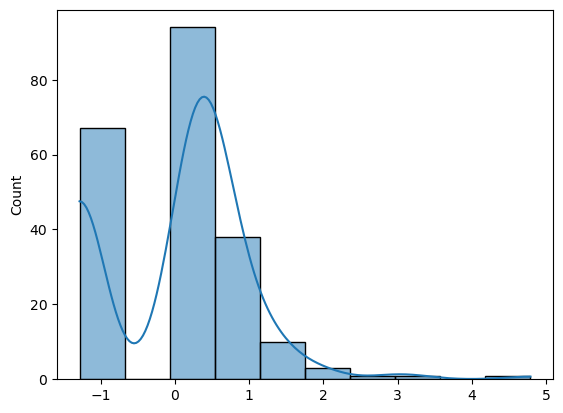

In [32]:
z_score=dsf.stdNBgraph(dataset["salary"])

#### 1.11 10)What is the probability Density Function of the salary range from 700000 to 900000?

C:\AI Learnings\5.DataScience\AssignmentDataScience\DatascienceAllFunctions.py:100: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  ax = sns.distplot(dataset,kde=True,kde_kws={'color':'blue'},color='Green')


Mean=198702.326, Standard Deviation=154780.927
The area between range(70000,90000):0.038404601457347344


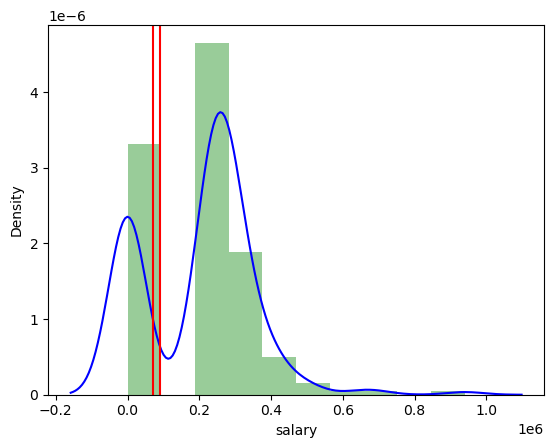

In [33]:
probablility=dsf.get_pdf_probability(dataset["salary"],70000,90000)

In [34]:
## From the above graph we can concule the PDF is 0.038
## The average Salary is around ₹2,00,000–₹3,00,000.
## Around 4% of the candidates are getting Salary in the range of 70000 to 90000

#### 1.12 11)Test the similarity between the degree_t(Sci&Tech)with respect to etest_p and mba_p at significance level of 5%.
#### (Make decision using Hypothesis Testing)

In [35]:
# H₀ (Null Hypothesis):There is no significant difference between etest_p and mba_p scores for Sci&Tech students.
# H₁ (Alternate Hypothesis):There is a significant difference between the two scores.

In [36]:
## USe ANOVA in this case


sci_tech = dataset[dataset['degree_t'] == 'Sci&Tech']
result = stats.f_oneway(sci_tech['etest_p'],sci_tech['mba_p'])
p_value = result.pvalue
p_value

np.float64(1.4289217003775155e-05)

In [37]:
## Basesd on the above result p_value 0.000014289217003775155 is significantly lower than 0.05
## Conclusion Accept null Hypothesis 
## There is no significant difference between etest_p and mba_p scores for Sci&Tech students.

#### 1.13 12)Which parameter is highly correlated with salary?

In [38]:
# Compute correlation with salary
corr_salary = placed.corr(numeric_only=True)['salary']

# Sort correlations in Ascending order
corr_salary_sort = corr_salary.sort_values(ascending=True)

print(corr_salary_sort)


degree_p   -0.019272
ssc_p       0.035330
hsc_p       0.076819
mba_p       0.175013
etest_p     0.178307
salary      1.000000
Name: salary, dtype: float64


In [39]:
## Based on the above test results , It shows etest_p has high correlation with Salary

#### 1.14 13) plot any useful graph and explain it.

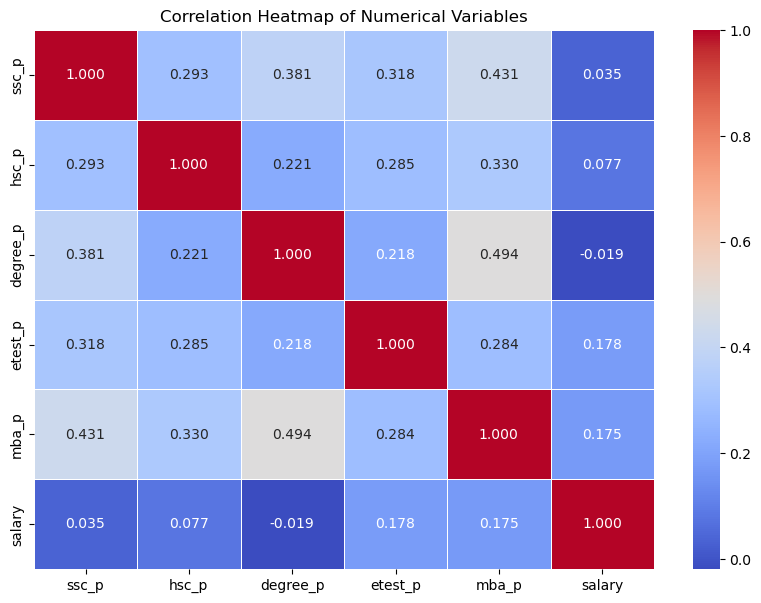

In [40]:
## Got this code from Internet which helps in uderstanding the correlation chart
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

data = placed.select_dtypes(include=['int64', 'float64'])

# Compute correlation matrix
corr_matrix = data.corr()

# Plot heatmap
plt.figure(figsize=(10, 7))
sns.heatmap(corr_matrix,annot=True,cmap='coolwarm',fmt=".3f",linewidths=0.5)
plt.title("Correlation Heatmap of Numerical Variables")
plt.show()


In [41]:
## Created this graph to understand the Correlation of each univariates
## Based on the above graph we can confirm that etest_p is highly correlated with Salary